INTRODUCCIÓN

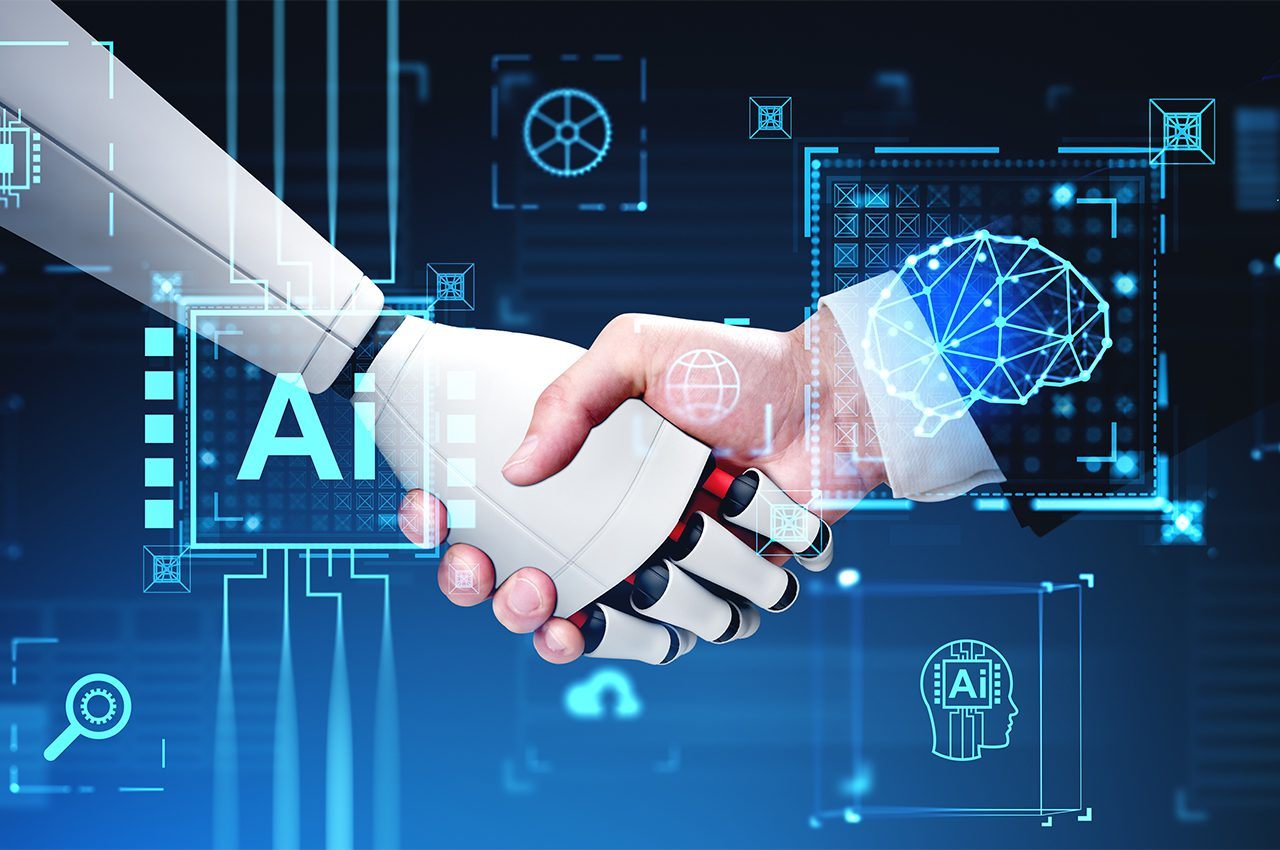

##Carga del Data-Set

###Carga de librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import tensorflow as tf
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score


from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score


###Conexión Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Importacion del data set

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/IA/Poryecto/ai_skepticism_dataset.csv")

##Impresion del Data-set

###Shape

In [ ]:
df.shape

(1000, 23)

###Head
Solo se muestran las 10 primeras filas, ya que el data st tiene 1000 filas.

In [ ]:
print("\nPrimeras 10 filas:")
df.head(10)


Primeras 10 filas:


,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
0,Claude,math_calculation,93.23,527,True,False,False,Moderate,45-54,Bachelors,...,Low,False,False,10.0,True,Google Search,10.7,80.15,True,Moderate Trust
1,Llama,recipe_cooking,84.47,581,False,False,False,Specific,55-64,PhD,...,NaN,False,True,7.9,True,Asked Expert,44.3,92.33,True,Skeptical
2,Claude,general_knowledge,69.82,484,True,True,False,Very Specific,35-44,High School,...,NaN,True,False,8.6,True,Consulted Documentation,37.5,67.32,True,Moderate Trust
3,Claude,creative_writing,79.61,73,True,True,False,Specific,45-54,Professional,...,NaN,NaN,False,8.9,True,Checked Official Source,22.7,73.12,True,Moderate Trust
4,Claude,creative_writing,67.71,146,False,True,False,Vague,55-64,Masters,...,NaN,True,True,9.0,True,Academic Paper,43.7,81.05,True,Moderate Trust
5,Mistral,math_calculation,93.41,198,False,True,False,Moderate,18-24,Professional,...,NaN,False,False,8.2,False,NaN,0.0,100.00,True,Blind Trust
6,Claude,technical_coding,75.87,285,False,False,True,Very Specific,18-24,High School,...,High,False,True,7.6,False,NaN,0.0,79.04,True,Moderate Trust
7,Claude,financial_advice,57.32,371,True,False,False,Vague,55-64,Professional,...,High,NaN,False,6.4,False,NaN,0.0,55.65,True,Moderate Trust
8,ChatGPT-3.5,medical_advice,50.17,344,False,False,True,Vague,65+,PhD,...,High,NaN,False,5.3,True,Personal Testing,20.0,41.69,True,Skeptical
9,Llama,medical_advice,58.77,63,False,False,True,Vague,65+,Professional,...,Low,False,False,5.6,True,Cross-referenced Multiple AIs,23.5,50.81,True,Skeptical


###Columnas

In [ ]:
print("\nColumnas:")
df.columns


Columnas:


Index(['ai_model_name', 'query_category', 'ai_confidence_percentage',
       'response_character_count', 'has_cited_sources',
       'contains_hedging_words', 'includes_disclaimer', 'answer_detail_level',
       'respondent_age_bracket', 'education_level', 'digital_literacy_score',
       'ai_familiarity_level', 'decision_importance', 'urgency_level',
       'belief_alignment_status', 'subject_matter_expertise',
       'trust_score_out_of_10', 'performed_fact_check',
       'fact_check_method_used', 'verification_duration_mins',
       'answer_accuracy_percentage', 'trust_calibration_valid',
       'user_skepticism_category'],
      dtype='object')

###Información
indice de columna, cantida de datos asociados, ¿nulos? y tipo de dato.

In [ ]:
print("\nInformación:")
df.info()


Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ai_model_name               1000 non-null   object 
 1   query_category              1000 non-null   object 
 2   ai_confidence_percentage    1000 non-null   float64
 3   response_character_count    1000 non-null   int64  
 4   has_cited_sources           1000 non-null   bool   
 5   contains_hedging_words      1000 non-null   bool   
 6   includes_disclaimer         1000 non-null   bool   
 7   answer_detail_level         1000 non-null   object 
 8   respondent_age_bracket      1000 non-null   object 
 9   education_level             1000 non-null   object 
 10  digital_literacy_score      1000 non-null   object 
 11  ai_familiarity_level        1000 non-null   object 
 12  decision_importance         1000 non-null   object 
 13  urgency_level       

###Descripcion estadistica de los datos
Media, varianza, minimos, percentiles y maximos.
Nota: Debido a que el dataset no cuenta con non-nulls. todas las columnas pueden ser utilizadas con regularidad.

In [ ]:
print("\nDescripción estadística:")
df.describe(percentiles=None, include=None, exclude=None)


Descripción estadística:


,ai_confidence_percentage,response_character_count,trust_score_out_of_10,verification_duration_mins,answer_accuracy_percentage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,72.006790,429.022000,7.905000,14.840000,69.982020
std,14.663334,221.644937,1.766866,15.182336,18.176782
min,40.520000,50.000000,1.800000,0.000000,19.420000
25%,60.570000,239.500000,6.700000,0.000000,58.570000
50%,74.235000,423.000000,8.200000,11.050000,72.080000
75%,83.862500,629.000000,9.500000,28.200000,83.140000
max,98.660000,799.000000,10.000000,45.000000,100.000000


###Descripción del significado de cada columna.
| Nombre de la columna       | Descripción                                                                                                         |
| -------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| ai_model_name              | Nombre del modelo de inteligencia artificial que generó la respuesta.                                               |
| query_category             | Categoría de la consulta realizada al modelo (por ejemplo: cálculo matemático, programación, consejo médico, etc.). |
| ai_confidence_percentage   | Porcentaje de confianza que el modelo de IA asigna a su respuesta.                                                  |
| response_character_count   | Número de caracteres que contiene la respuesta generada por el modelo.                                              |
| has_cited_sources          | Indica si la respuesta incluye fuentes citadas o referencias (True/False).                                          |
| contains_hedging_words     | Indica si la respuesta contiene lenguaje de incertidumbre como "podría", "posiblemente", etc.                       |
| includes_disclaimer        | Indica si la respuesta incluye un aviso o advertencia sobre la información proporcionada.                           |
| answer_detail_level        | Nivel de detalle de la respuesta (por ejemplo: vago, moderado, específico, muy específico).                         |
| respondent_age_bracket     | Grupo de edad de la persona que interactúa con el modelo de IA.                                                     |
| education_level            | Nivel educativo del usuario (por ejemplo: secundaria, licenciatura, doctorado).                                     |
| digital_literacy_score     | Puntuación que representa el nivel de alfabetización digital del usuario.                                           |
| ai_familiarity_level       | Nivel de familiaridad del usuario con tecnologías de inteligencia artificial.                                       |
| trust_score_out_of_10      | Nivel de confianza del usuario en la respuesta del modelo de IA en una escala de 1 a 10.                            |
| verification_duration_mins | Tiempo que el usuario tarda en verificar la información de la respuesta, medido en minutos.                         |
| answer_accuracy_percentage | Porcentaje estimado de precisión de la respuesta generada por la IA.                                                |
| belief_alignment_status    | Indica si la respuesta coincide con las creencias previas del usuario.                                              |
| urgency_level              | Nivel de urgencia de la consulta realizada (bajo, medio o alto).                                                    |


##Categorización de las columnas

###Columnas categóricas

Aqui debemos imprimir y buscar las columnas que tienen de tipo de dato, "object" y "category" en el dataset, luego imprimimos solamente la fila de columnas.

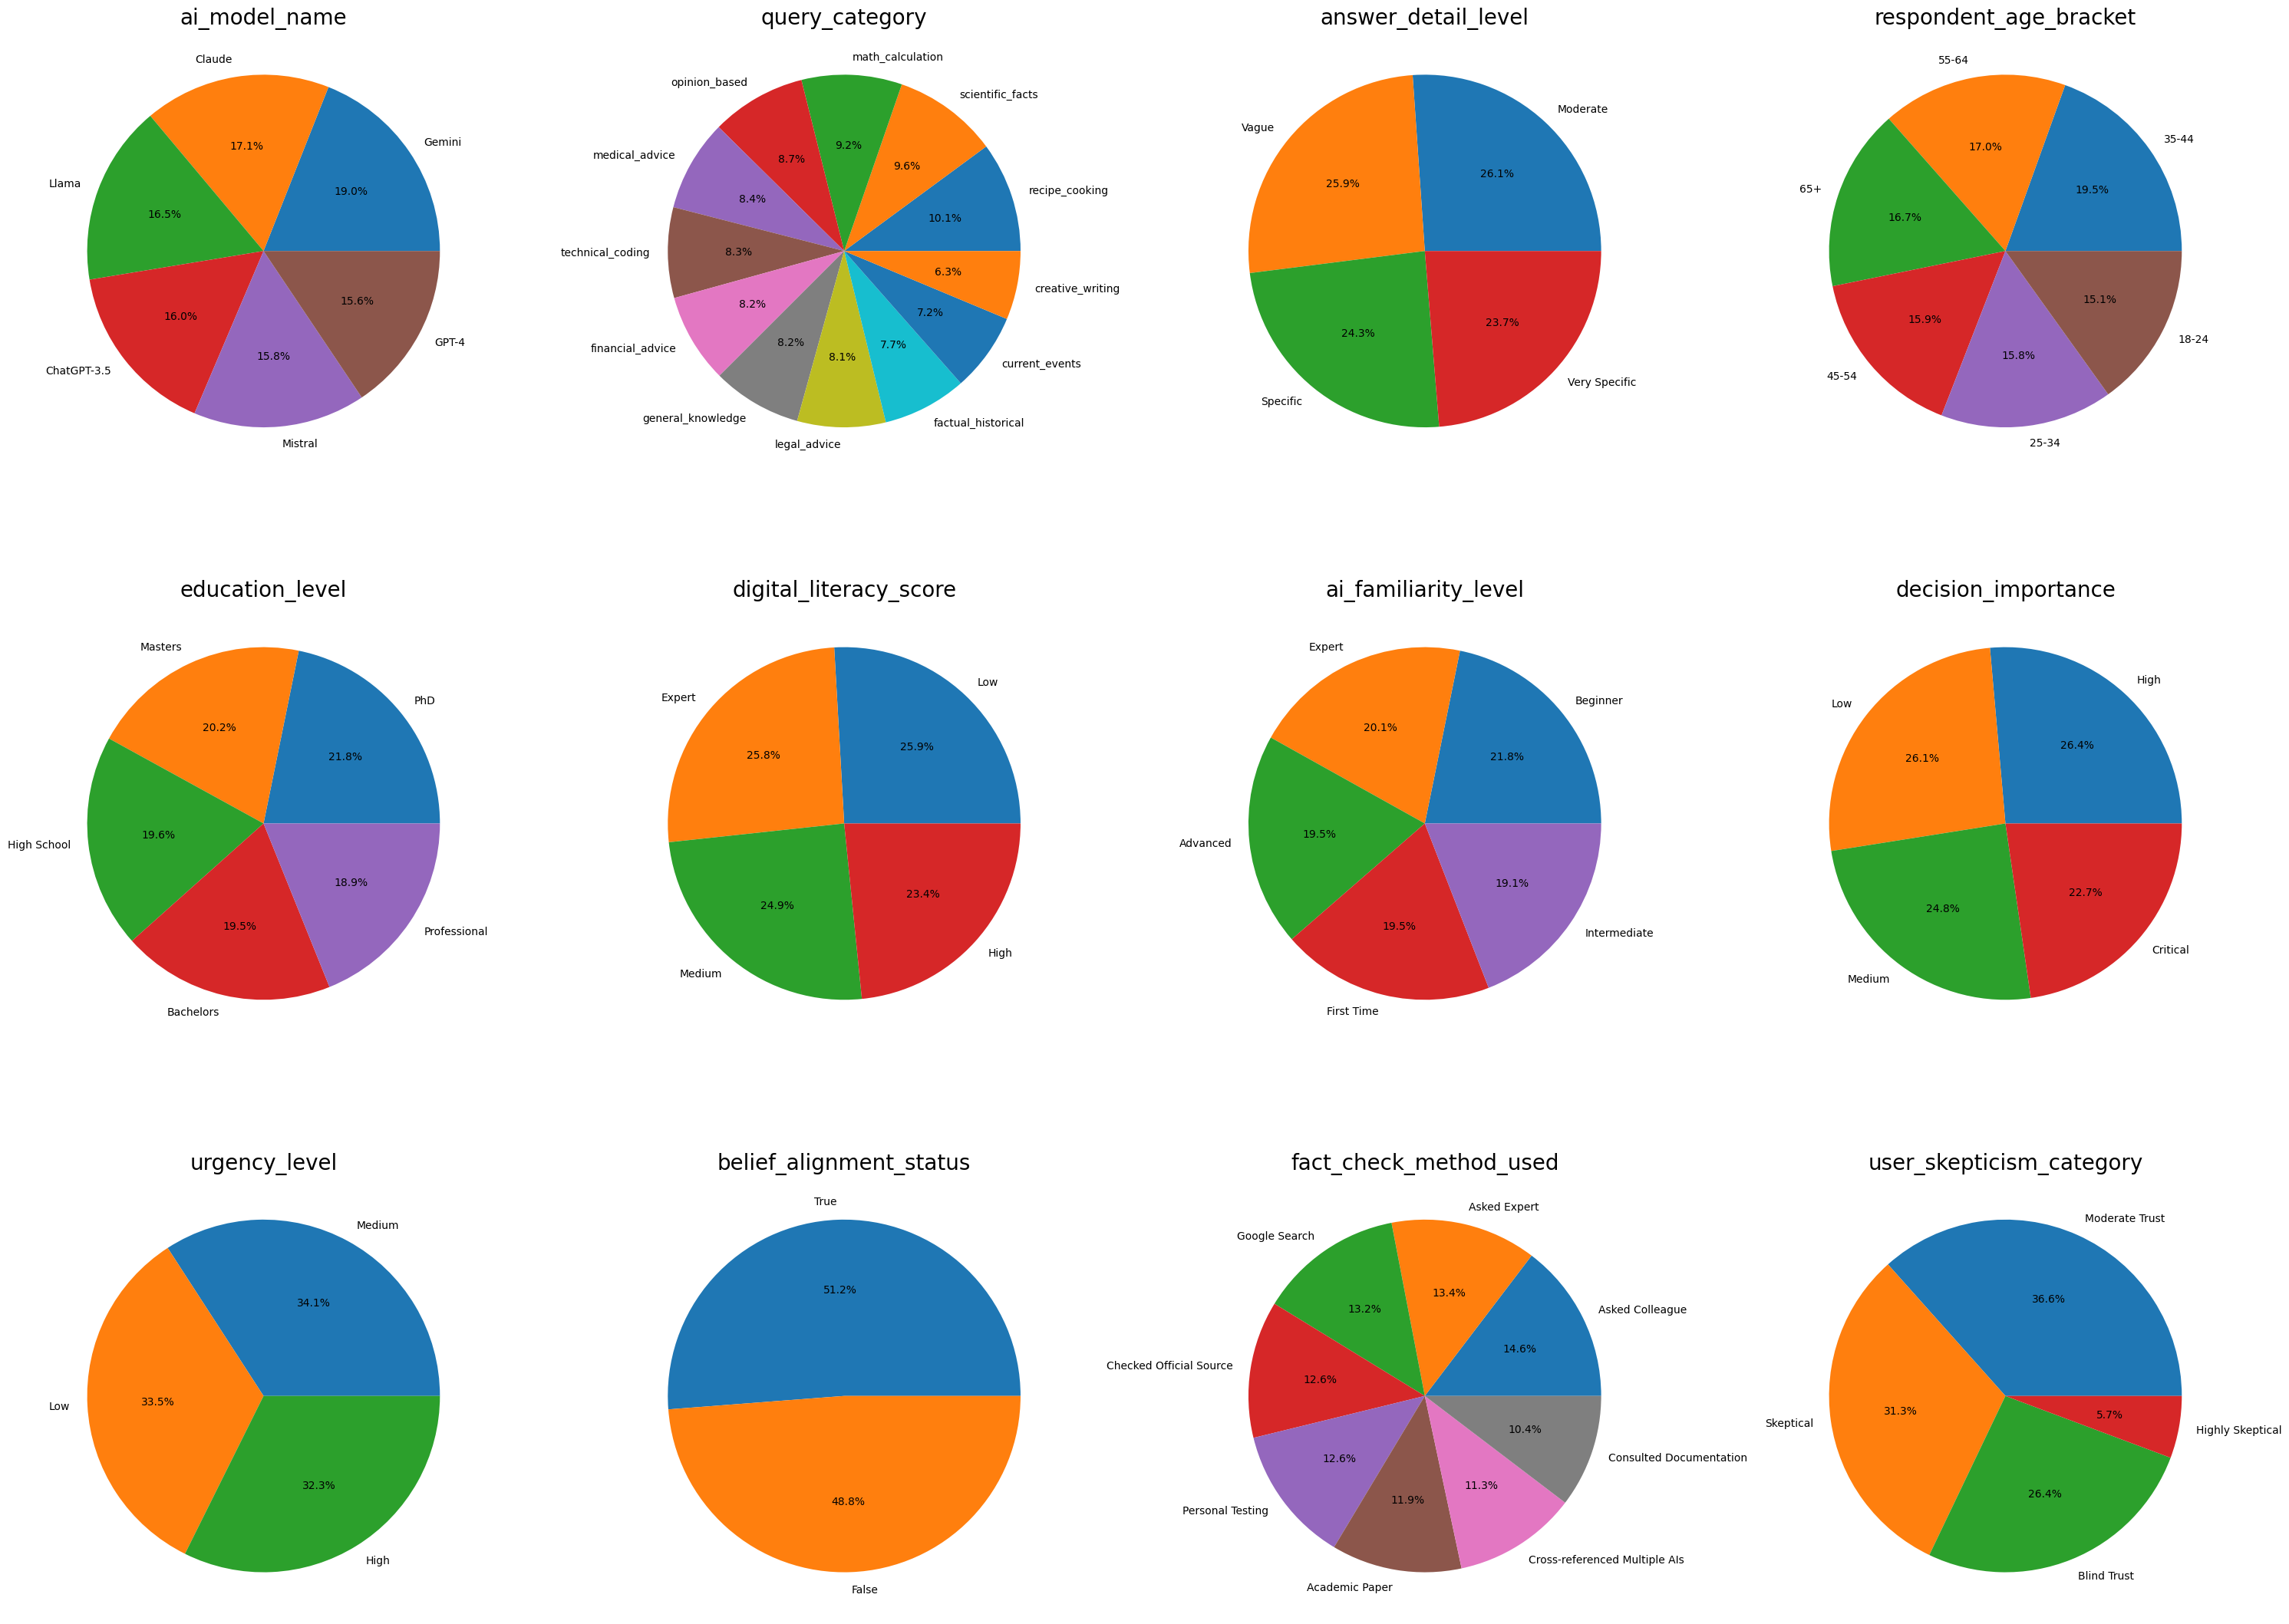

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category'])
#-------------------------GRAFICAS------------------------------

plt.figure(figsize=(30,30))

for i, col in enumerate(categorical_cols):

    plt.subplot(4,4,i+1)

    counts = df[col].value_counts()

    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

    plt.title(col, fontsize=20)

plt.tight_layout()
plt.show()


###Columnas Numéricas

Porcentaje de confianza, numero de caracteres de respuestas, puntuacion de confianza, duracion de verificacion y porcentaje de precision de respuesta.

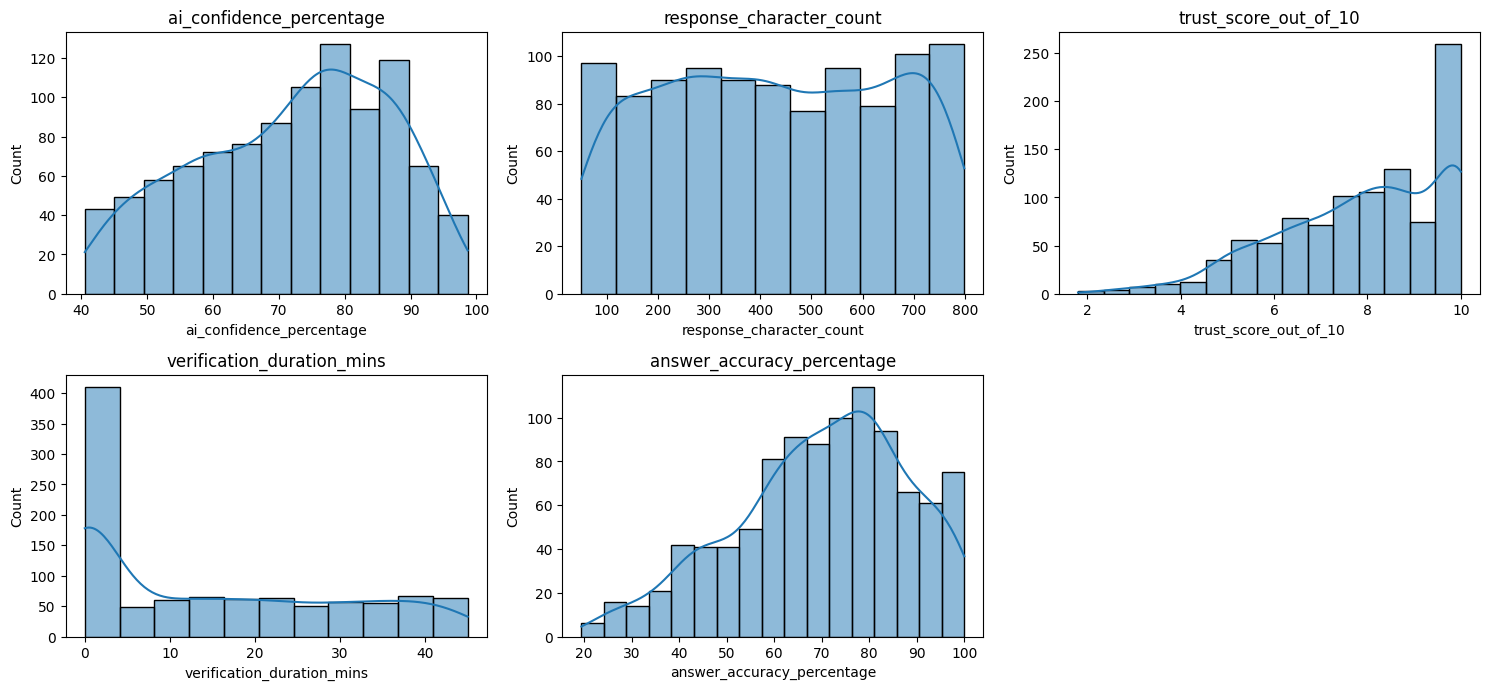

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

#-------------------------GRAFICAS------------------------------


plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols):

    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True)

    plt.title(col)

plt.tight_layout()
plt.show()

##Outliers
Basicamente miramos cuales de los datos estan muy separados de la media poblacional, en este caso, para las columnas numericas, hacemos la operacion:

$Outlier(low) = Q1 - 1.5 * IQR $

$Outlier(low) = Q1 - 1.5 * IQR $


In [ ]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    print(Q1)
    Q3 = df[col].quantile(0.75)
    print(Q3)
    IQR = Q3 - Q1
    print(IQR)

    lower = Q1 - 1.5 * IQR
    print(lower)
    upper = Q3 + 1.5 * IQR
    print(upper)
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

col = "trust_score_out_of_10"   # cambia por la columna que tenga outliers

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]

outliers

60.57
83.8625
23.292499999999997
25.63125
118.80125
ai_confidence_percentage: 0 outliers
239.5
629.0
389.5
-344.75
1213.25
response_character_count: 0 outliers
6.7
9.5
2.8
2.500000000000001
13.7
trust_score_out_of_10: 3 outliers
0.0
28.2
28.2
-42.3
70.5
verification_duration_mins: 0 outliers
58.57
83.14
24.57
21.714999999999996
119.995
answer_accuracy_percentage: 3 outliers


,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
218,ChatGPT-3.5,opinion_based,41.66,782,False,False,False,Vague,45-54,Professional,...,Low,False,False,2.3,True,Academic Paper,34.3,24.18,True,Highly Skeptical
299,Gemini,financial_advice,44.99,405,False,True,True,Vague,65+,High School,...,Low,False,True,1.8,True,Google Search,32.7,42.14,False,Highly Skeptical
743,Gemini,financial_advice,48.41,798,False,True,True,Vague,55-64,Masters,...,Medium,False,False,2.3,True,Asked Expert,17.9,51.08,False,Highly Skeptical


###Eliminación de outliers

Como se podrá observar, el dataset presenta muy pocos outliers, redefinimos el dataset sin estos outliers y imprimimos las dimesiones, donde se eliminan 3 filas.

In [ ]:
df = df[(df[col] >= lower) & (df[col] <= upper)]

df.shape

(997, 23)

##PASAR TEXTO A NUMERO

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = pd.factorize(df[col])[0]

df.head()

,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
0,0,0,93.23,527,True,False,False,0,0,0,...,0,0,False,10.0,True,0,10.7,80.15,True,0
1,1,1,84.47,581,False,False,False,1,1,1,...,-1,0,True,7.9,True,1,44.3,92.33,True,1
2,0,2,69.82,484,True,True,False,2,2,2,...,-1,1,False,8.6,True,2,37.5,67.32,True,0
3,0,3,79.61,73,True,True,False,1,0,3,...,-1,-1,False,8.9,True,3,22.7,73.12,True,0
4,0,3,67.71,146,False,True,False,3,1,4,...,-1,1,True,9.0,True,4,43.7,81.05,True,0


###Verificacion del estado de los tipos de dato

In [ ]:
df.dtypes

,0
ai_model_name,int64
query_category,int64
ai_confidence_percentage,float64
response_character_count,int64
has_cited_sources,bool
contains_hedging_words,bool
includes_disclaimer,bool
answer_detail_level,int64
respondent_age_bracket,int64
education_level,int64


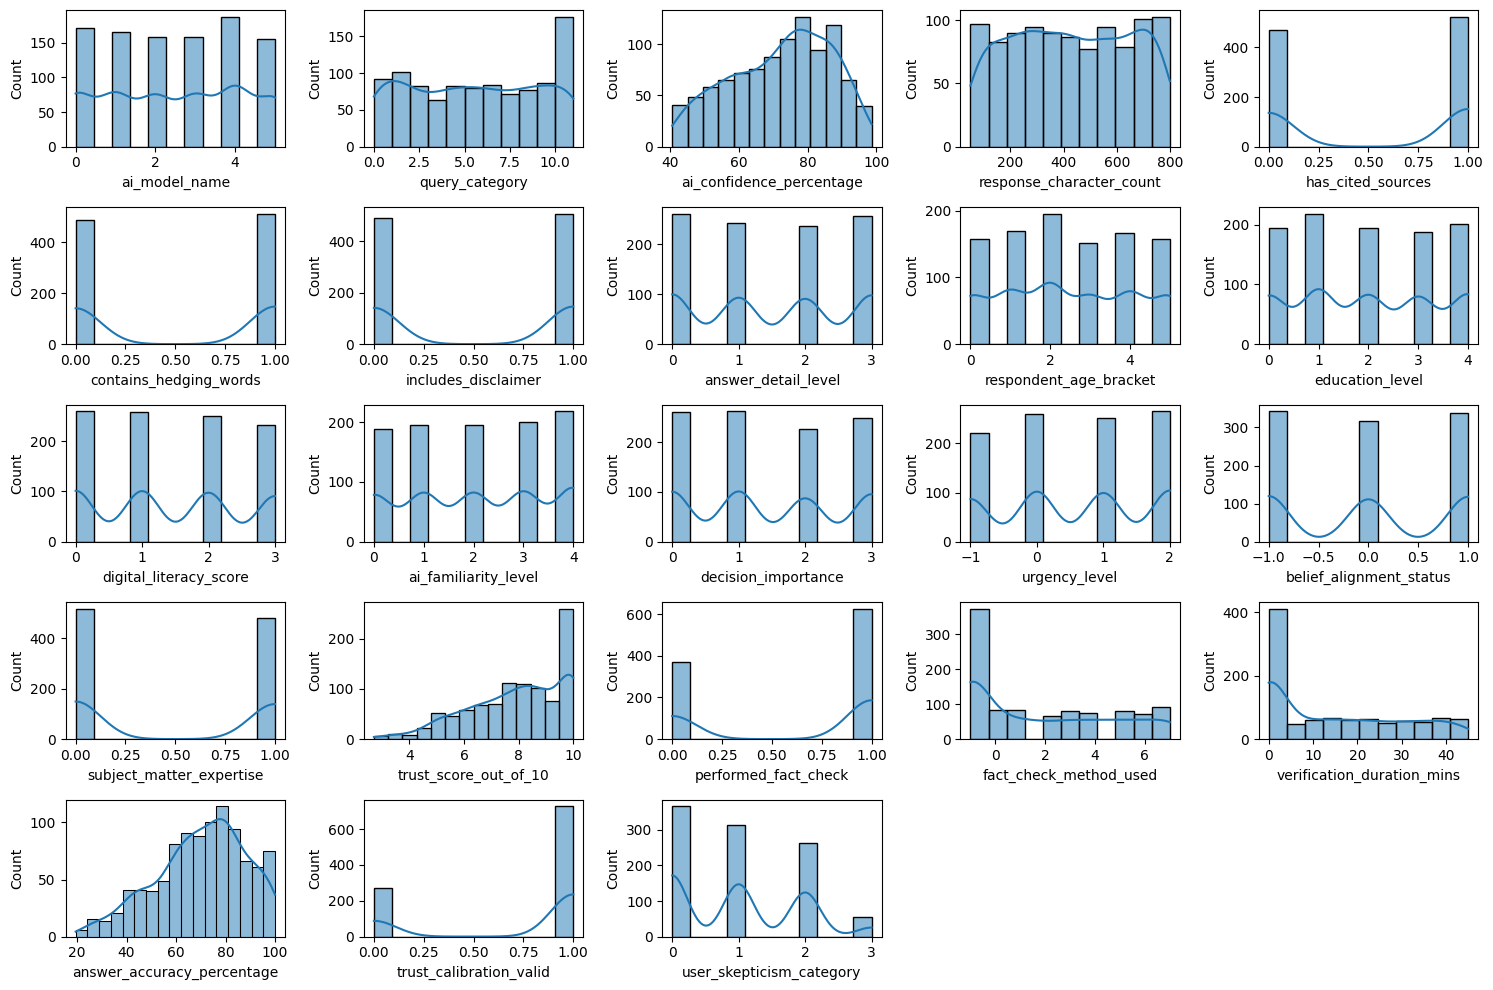

In [ ]:
columnas = df.columns

#-------------------------GRAFICAS------------------------------


plt.figure(figsize=(15,10))

for i, col in enumerate(columnas):

    plt.subplot(5,5,i+1)
    sns.histplot(df[col], kde=True)



plt.tight_layout()
plt.show()

#Problema de CLASIFICACION

El problema se plantea como un problema de clasificación, ya que la variable objetivo corresponde a categorías discretas y no a valores numéricos continuos.
En este tipo de problema, el objetivo del modelo es asignar una observación a una clase específica dentro de un conjunto finito de categorías.


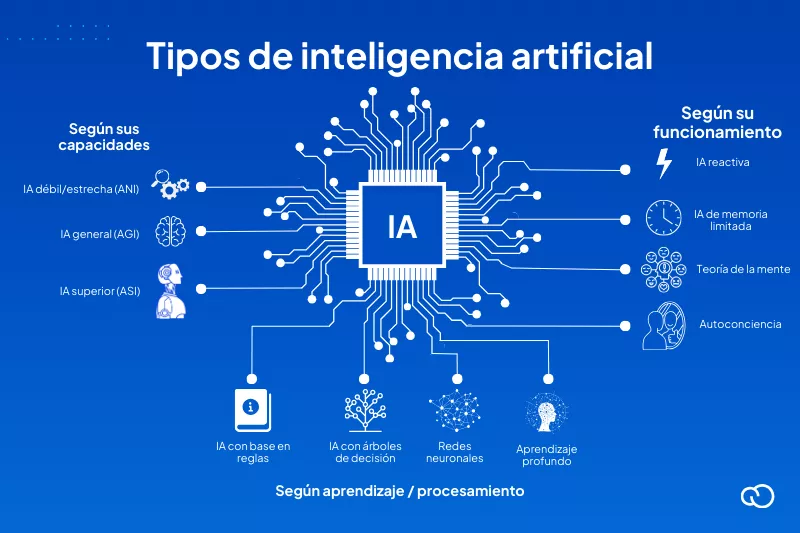

Ejemplo: si el usuario busca cual es la mejor IA para hacer una tarea en especifico, en un tiempo especifico, con un acierto muy bueno y un buen desempeño, por eso es clasificacion, ya que estariamos seleccionando cual es la mejor ia para hacer "x actividad"



# 2da entrega - Introducción

Contexto, elegimos la columna "trust_calibration_valid", ya que está sera la mejor para indicar si la confianza del usuario es acertada o no.


#Limpieza de dataset

eliminamos los nulos (NaN, null, etc...)

In [ ]:
# Ver info general
print(df.info())
print(df.isnull().sum())

# Manejo de nulos (ejemplo)
df = df.dropna()  # o imputar:
# df.fillna(df.mean(), inplace=True)

# (opcional) eliminar duplicados
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
Index: 997 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ai_model_name               997 non-null    int64  
 1   query_category              997 non-null    int64  
 2   ai_confidence_percentage    997 non-null    float64
 3   response_character_count    997 non-null    int64  
 4   has_cited_sources           997 non-null    bool   
 5   contains_hedging_words      997 non-null    bool   
 6   includes_disclaimer         997 non-null    bool   
 7   answer_detail_level         997 non-null    int64  
 8   respondent_age_bracket      997 non-null    int64  
 9   education_level             997 non-null    int64  
 10  digital_literacy_score      997 non-null    int64  
 11  ai_familiarity_level        997 non-null    int64  
 12  decision_importance         997 non-null    int64  
 13  urgency_level               997 non-null

#X_test y Ground truth

Definimos X, que sera nuestros datos de entrenamiento
y nuestro ground truth

Elimino variables que pueden hacer "leakage" que seria que filtren el objetivo de clasificación del proyecto.

In [ ]:
X = df.drop([
    "trust_calibration_valid",
    "trust_score_out_of_10",
    "answer_accuracy_percentage"
], axis=1)

y = df["trust_calibration_valid"].astype(int)

#Estandarización y conversion de booleanos

SVM usa distancias, si no hay escalas, una variable domina sobre las demas

Deep Learning mejor su eficiencia


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

#Train / test split 80/20 + shuffle

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=True,random_state=42)

#Cross validation k=10

Divide los datos en 10 partes (folds)
Hace esto 10 veces:
entrena con 9 partes
prueba con 1 parte
Obtiene 10 resultados


In [ ]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
scores = cross_val_score(model, X_train, y_train, cv=10)
print(scores.mean())

0.7014240506329115


¿Qué es GridSearchCV?

Es una herramienta de scikit-learn que sirve para ayudar a hacer el tuning de manera automatica y no manual

probar automáticamente muchas combinaciones de parámetros y elegir la mejor

Problema que resuelve

Cuando usas un modelo, tienes parámetros como:

Decision Tree → max_depth
Random Forest → n_estimators
SVM → kernel

#Desicion tree

In [ ]:
cv = 10

param_dt = {"max_depth": [3, 5, 10]}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(),
    param_dt,
    cv=cv
)

grid_dt.fit(X_train, y_train)
dt_best = grid_dt.best_estimator_

In [ ]:
results = grid_dt.cv_results_

mean_scores = results["mean_test_score"]
depths = results["param_max_depth"]




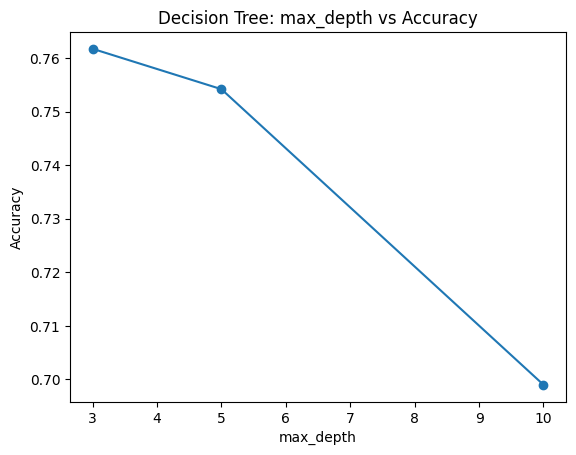

In [ ]:
import matplotlib.pyplot as plt

plt.plot(depths, mean_scores, marker='o')
plt.title("Decision Tree: max_depth vs Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.show()

#Random Forest

In [ ]:
param_rf = {"n_estimators": [50, 100, 200]}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_rf,
    cv=cv
)

grid_rf.fit(X_train, y_train)
rf_best = grid_rf.best_estimator_

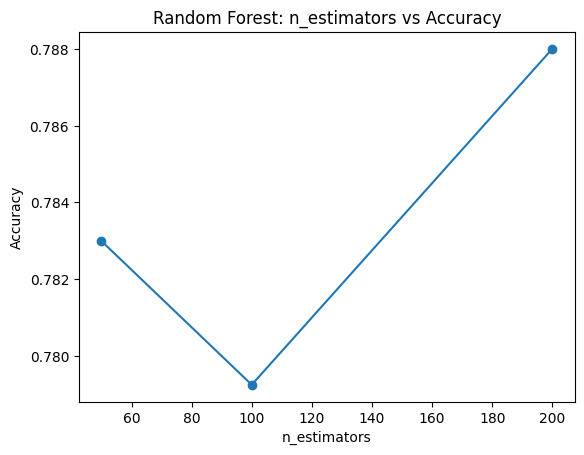

In [ ]:
results_rf = grid_rf.cv_results_

n_estimators = results_rf["param_n_estimators"]
mean_scores = results_rf["mean_test_score"]

import matplotlib.pyplot as plt

plt.plot(n_estimators, mean_scores, marker='o')
plt.title("Random Forest: n_estimators vs Accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

#SVC (Support Vector Machine)

In [ ]:
param_svm = {"kernel": ["linear", "poly", "rbf"]}

grid_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=cv
)

grid_svm.fit(X_train, y_train)
svm_best = grid_svm.best_estimator_

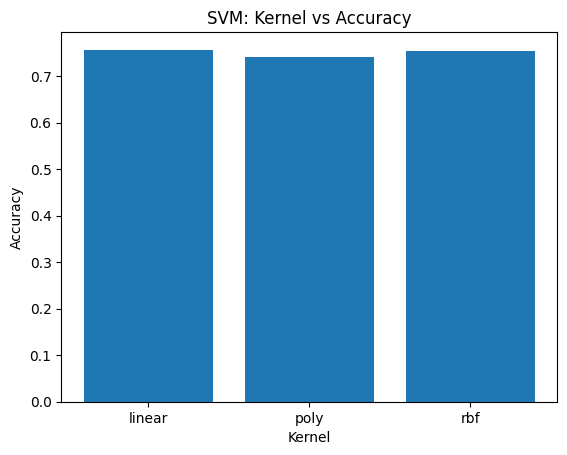

In [ ]:
results_svm = grid_svm.cv_results_

kernels = results_svm["param_kernel"]
mean_scores = results_svm["mean_test_score"]

import matplotlib.pyplot as plt

plt.bar(kernels, mean_scores)
plt.title("SVM: Kernel vs Accuracy")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.show()


Deep Learning

In [ ]:
print("Modelo 1")

for e in [10, 50, 100]:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=e, validation_split=0.2, verbose=0)

    y_pred = model.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    print(f"Epochs {e}: {acc}")

print("Modelo 2")

for e in [10, 50, 100]:
    model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model2.fit(X_train, y_train, epochs=e, validation_split=0.2, verbose=0)

    y_pred = model2.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    print(f"Epochs {e}: {acc}")

print("Modelo 3")

for e in [10, 50, 100]:
    model3 = tf.keras.Sequential()
    model3.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    for _ in range(10):
        model3.add(tf.keras.layers.Dense(128, activation='relu'))

    model3.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model3.fit(X_train, y_train, epochs=e, validation_split=0.2, verbose=0)

    y_pred = model3.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    print(f"Epochs {e}: {acc}")


Modelo 1


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epochs 10: 0.745


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epochs 10: 0.69


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epochs 50: 0.7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epochs 100: 0.74
Modelo 3
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epochs 10: 0.715
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epochs 50: 0.735
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epochs 100: 0.665


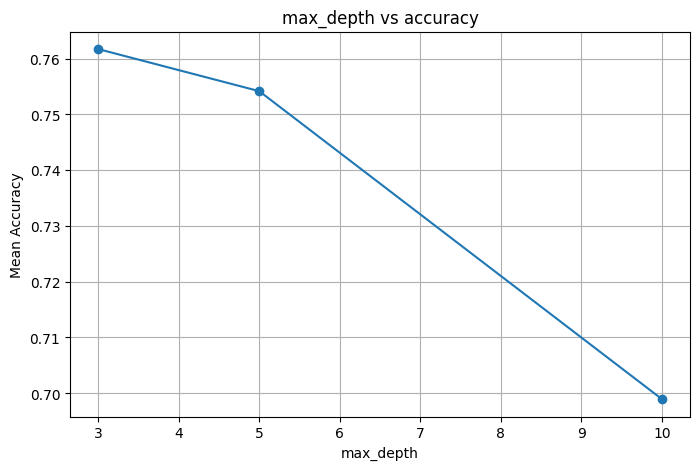

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    results['param_max_depth'],
    results['mean_test_score'],
    marker='o'
)

plt.title("max_depth vs accuracy")
plt.xlabel("max_depth")
plt.ylabel("Mean Accuracy")

plt.grid(True)
plt.show()

#Resultados

In [ ]:
from sklearn.metrics import accuracy_score

results = {}

# Modelos clásicos
for name, model in {
    "DT": dt_best,
    "RF": rf_best,
    "SVM": svm_best
}.items():
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

# Deep Learning
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results["DL"] = acc

#GRAFICAS

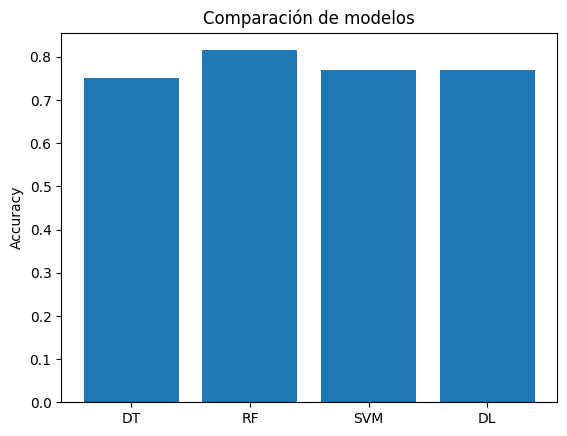

In [ ]:
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Comparación de modelos")
plt.show()

#3 entregable

elegimos variables numericas que posteriormente seran usadas en K means y DBSCAN

In [ ]:
X = df.select_dtypes(include=[np.number])

print(X.head())
print(X.shape)

   ai_model_name  query_category  ai_confidence_percentage  \
0              0               0                     93.23   
1              1               1                     84.47   
2              0               2                     69.82   
3              0               3                     79.61   
4              0               3                     67.71   

   response_character_count  answer_detail_level  respondent_age_bracket  \
0                       527                    0                       0   
1                       581                    1                       1   
2                       484                    2                       2   
3                        73                    1                       0   
4                       146                    3                       1   

   education_level  digital_literacy_score  ai_familiarity_level  \
0                0                       0                     0   
1                1                

## Escalado Min-Max

La fórmula del escalado Min-Max es:


$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Esto transforma todos los valores al rango:

[0,1]

In [ ]:
X_manual = (X - X.min()) / (X.max() - X.min())

print(X_manual.head())

   ai_model_name  query_category  ai_confidence_percentage  \
0            0.0        0.000000                  0.906605   
1            0.2        0.090909                  0.755934   
2            0.0        0.181818                  0.503956   
3            0.0        0.272727                  0.672343   
4            0.0        0.272727                  0.467664   

   response_character_count  answer_detail_level  respondent_age_bracket  \
0                  0.636849             0.000000                     0.0   
1                  0.708945             0.333333                     0.2   
2                  0.579439             0.666667                     0.4   
3                  0.030708             0.333333                     0.0   
4                  0.128171             1.000000                     0.2   

   education_level  digital_literacy_score  ai_familiarity_level  \
0             0.00                0.000000                  0.00   
1             0.25                

#PCA (Reducción de dimensionalidad)

Queremos reducir:

numero_columnas→2 componentes

Esto permitirá visualizar el dataset en 2D.

Shape original: (997, 5)
Shape PCA: (997, 2)
Varianza explicada por cada componente:
[0.49510578 0.2032632 ]
Varianza total explicada:
0.6983689858388603


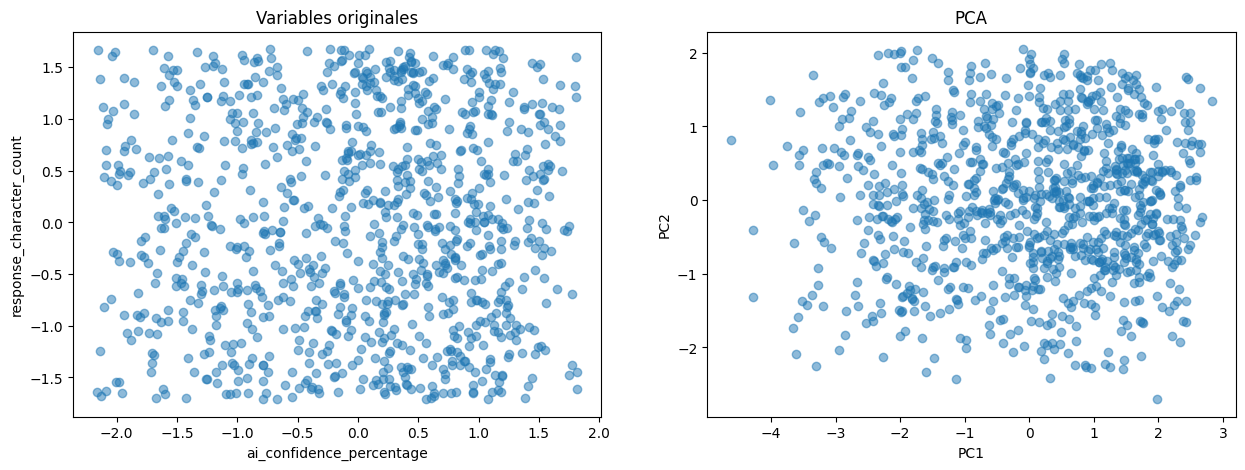

In [ ]:
# @title
from sklearn.decomposition import PCA

# ==========================================
# PCA
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Shape original:", X_scaled.shape)
print("Shape PCA:", X_pca.shape)

# ==========================================
# Varianza explicada
# ==========================================

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("Varianza total explicada:")
print(np.sum(pca.explained_variance_ratio_))

# ==========================================
# Comparación visual
# ==========================================

plt.figure(figsize=(15,5))

# -------------------------
# Variables originales
# -------------------------

plt.subplot(121)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    alpha=0.5
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])

plt.title("Variables originales")

# -------------------------
# PCA
# -------------------------

plt.subplot(122)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA")

plt.show()

##K-MEANS

n_clusters = numero_de_clases


In [ ]:
# @title
n_clusters = 3

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_pca)


In [ ]:
pca_df['KMeans_Cluster'] = kmeans_labels

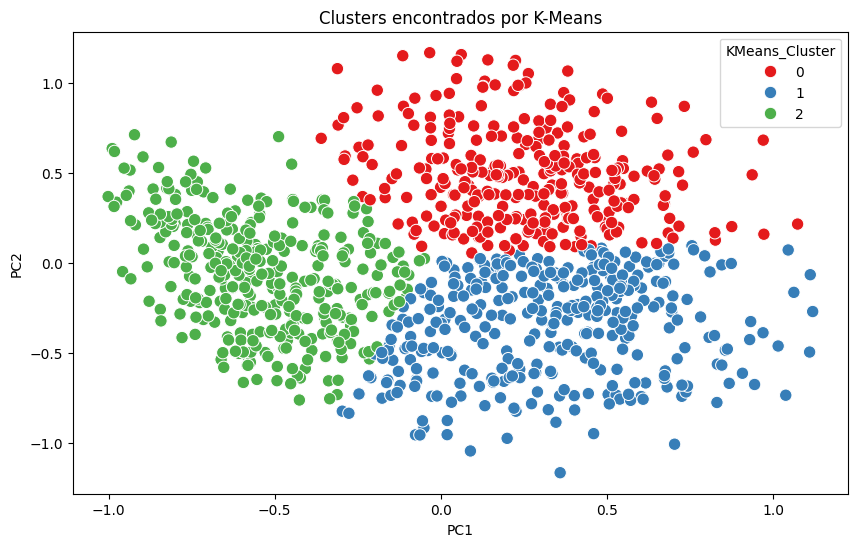

In [ ]:
# @title
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    palette='Set1',
    data=pca_df,
    s=80
)

plt.title('Clusters encontrados por K-Means')
plt.show()

##DBSCAN
Es necesario definir:

eps: se elije donde empieza a cambiar de direccion, como en el "codo".
min_samples: empezamos con 5.

In [ ]:
# @title
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

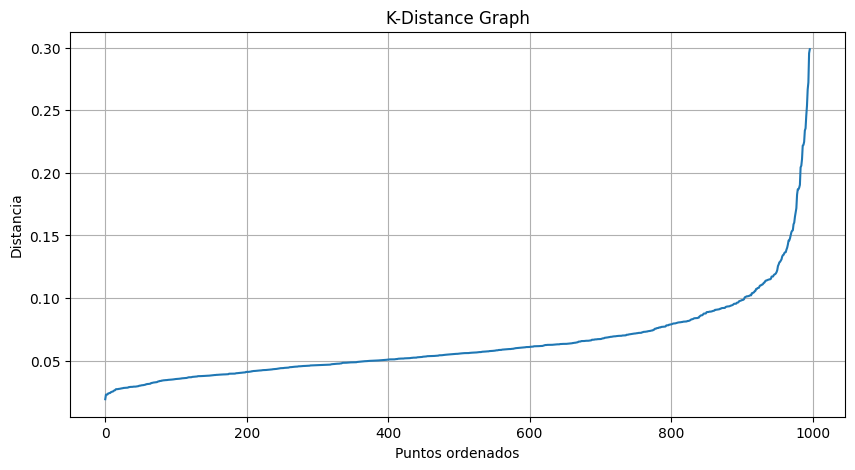

In [ ]:
# @title
distances = np.sort(distances[:,4])

plt.figure(figsize=(10,5))
plt.plot(distances)
plt.title('K-Distance Graph')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia')
plt.grid(True)
plt.show()

   ai_confidence_percentage  response_character_count  trust_score_out_of_10  \
0                     93.23                       527                   10.0   
1                     84.47                       581                    7.9   
2                     69.82                       484                    8.6   
3                     79.61                        73                    8.9   
4                     67.71                       146                    9.0   

   verification_duration_mins  answer_accuracy_percentage  
0                        10.7                       80.15  
1                        44.3                       92.33  
2                        37.5                       67.32  
3                        22.7                       73.12  
4                        43.7                       81.05  
Clusters encontrados:
[-1]
Ruido/Outliers: 997


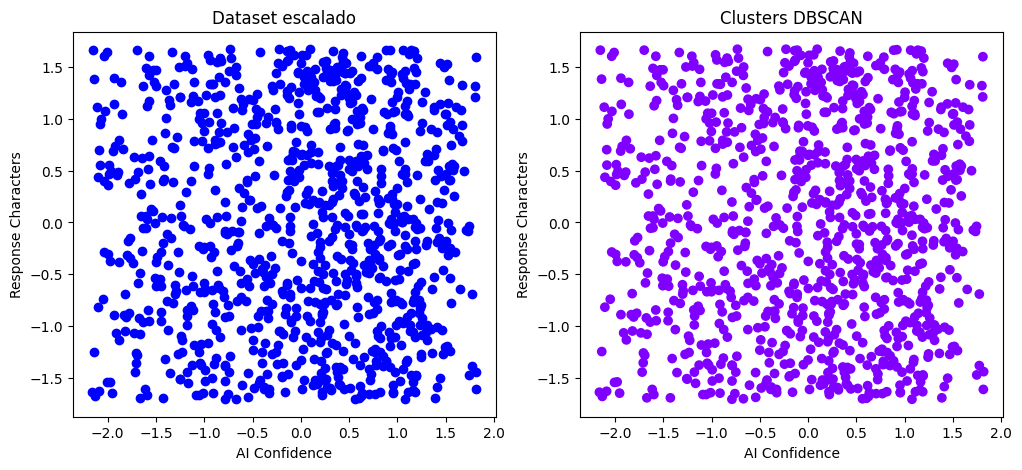

In [ ]:
#@title **DBSCAN aplicado al dataset AI Skepticism**

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# ==========================================
# 1. Seleccionar SOLO variables numéricas útiles
# ==========================================

X = df[[
    'ai_confidence_percentage',
    'response_character_count',
    'trust_score_out_of_10',
    'verification_duration_mins',
    'answer_accuracy_percentage'
]]

print(X.head())

# ==========================================
# 2. Escalar
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. DBSCAN
# ==========================================

DBS = DBSCAN(
    eps=0.1,
    min_samples=8
)

DBS.fit(X_scaled)

labels = DBS.labels_

# ==========================================
# 4. Información clusters
# ==========================================

print("Clusters encontrados:")
print(np.unique(labels))

unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):

    if u == -1:
        print(f"Ruido/Outliers: {c}")

    else:
        print(f"Cluster {u}: {c}")

# ==========================================
# 5. Gráfica
# ==========================================

plt.figure(figsize=(12,5))

# ----------------------
# Datos originales
# ----------------------

plt.subplot(121)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c='blue'
)

plt.xlabel("AI Confidence")
plt.ylabel("Response Characters")

plt.title("Dataset escalado")

# ----------------------
# DBSCAN
# ----------------------

plt.subplot(122)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels,
    cmap='rainbow'
)

plt.xlabel("AI Confidence")
plt.ylabel("Response Characters")

plt.title("Clusters DBSCAN")

plt.show()

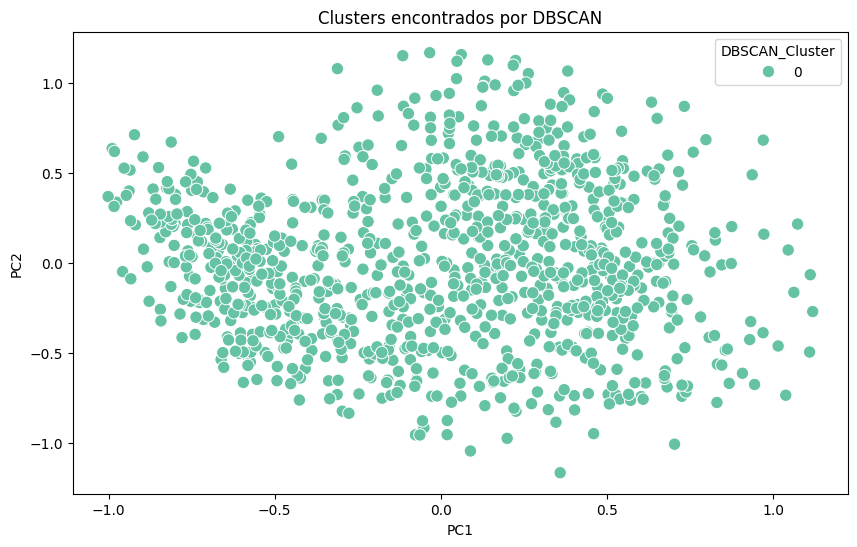

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette='Set2',
    data=pca_df,
    s=80
)

plt.title('Clusters encontrados por DBSCAN')
plt.show()